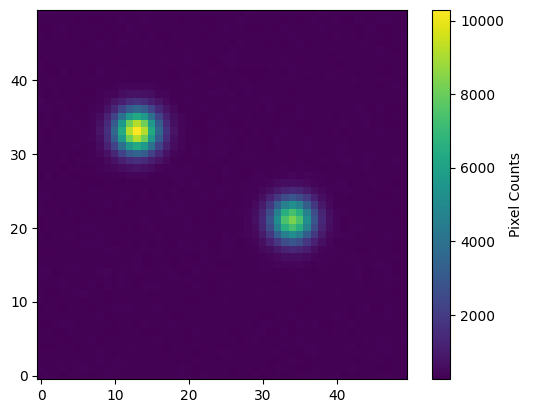

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def generate_two_stars():
 
    image = np.random.normal(loc=300, scale=20, size=(50, 50))
    y, x = np.mgrid[0:50, 0:50]

    #star 1
    distance_sq_1 = (x - 13)**2 + (y - 33)**2
    star1_flux = 10000 * np.exp(-distance_sq_1 / 8)

    #star 2
    distance_sq_2 = (x - 34)**2 + (y - 21)**2
    star2_flux = 8000 * np.exp(-distance_sq_2 / 8)
    

 
    image += star1_flux + star2_flux
    return image, distance_sq_1, distance_sq_2

image, distance_sq_1, distance_sq_2 = generate_two_stars()



plt.imshow(image, cmap='viridis', origin='lower')
plt.colorbar(label='Pixel Counts')
plt.show()

In [3]:
def m_inst(image, x_c, y_c, tol, app, ann_1, ann_2):
    rows, cols = image.shape
    
    # Calculate local maximum in a 20x20 box around the star
    local_box = image[max(0, y_c-10):min(rows, y_c+11), max(0, x_c-10):min(cols, x_c+11)]
    m = np.max(local_box)

    # Calculate FWHM from pixels near Half-Maximum inside the local box
    coords = np.argwhere(np.abs(local_box - m/2) <= (tol * (m / 2)))
    global_coords = coords + np.array([max(0, y_c-10), max(0, x_c-10)])
    hm_distances = np.sqrt((global_coords[:, 1] - x_c)**2 + (global_coords[:, 0] - y_c)**2)
    fwhm = 2 * np.mean(hm_distances)
    
    # Define sizes
    ap = app * fwhm
    ann_in = ann_1 * fwhm
    ann_out = ann_2 * fwhm

    # Create a full distance map for the entire image grid
    c, d = np.mgrid[0:rows, 0:cols]
    all_distances = np.sqrt((d - x_c)**2 + (c - y_c)**2)

    # Annulus background calculation
    ann_flux_values = image[(all_distances >= ann_in) & (all_distances <= ann_out)]
    bkg = np.median(ann_flux_values)

    # Aperture star flux calculation
    ap_flux_values = image[all_distances <= ap]
    flux = np.sum(ap_flux_values)

    # Background subtraction and magnitude calculation
    signal = flux - (bkg * len(ap_flux_values))
    m_inst = -2.5 * np.log10(signal)

    return m_inst


def find_stars(image, tol, window_size):
    rows, cols = image.shape
    radius = window_size // 2
    
    # This list will store the (x, y) coordinates of all detected stars
    star_centers = []

    # Step 1: Loop through every single pixel in the image (skipping edges)
    for r in range(radius, rows - radius):
        for c in range(radius, cols - radius):
            
            # Step 2: Slice out the local window around the current pixel (r, c)
            window = image[r - radius : r + radius + 1, c - radius : c + radius + 1]
            
            # Step 3: Calculate the local background statistics
            m_local = np.median(window)
            s_local = np.std(window)
            
            current_pixel_value = image[r, c]
            
            # Condition A: Is this pixel significantly brighter than the background noise?
            if current_pixel_value > (m_local + tol * s_local):
                
                # Condition B: Is this pixel the absolute brightest pixel in this window?
                # (This ensures we only grab the true center peak of the star)
                if current_pixel_value == np.max(window):
                    
                    # We found a unique star center! Save it.
                    star_centers.append((r, c))
                    
    return star_centers

In [4]:
#Finding the stars in our code
star_centers = find_stars(image, 5, 20)

for star in star_centers:
    b,a = star
    mag = m_inst(image, a, b, 0.2, 1.25, 4, 6)

    print(f"Star at x={a}, y={b} -> Instrumental Magnitude: {mag:.4f}")


Star at x=34, y=21 -> Instrumental Magnitude: -13.2350
Star at x=13, y=33 -> Instrumental Magnitude: -13.4776
